In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Load the synthetic dataset
df = pd.read_csv("../data/synthetic/users_weight_data.csv")

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")


Dataset loaded: (45000, 15)
Columns: ['user_id', 'gender', 'age', 'height_cm', 'start_weight_kg', 'activity_level', 'goal', 'disease', 'adherence', 'metabolic_adapt_rate', 'bmr', 'tdee', 'target_daily_delta', 'day', 'weight']


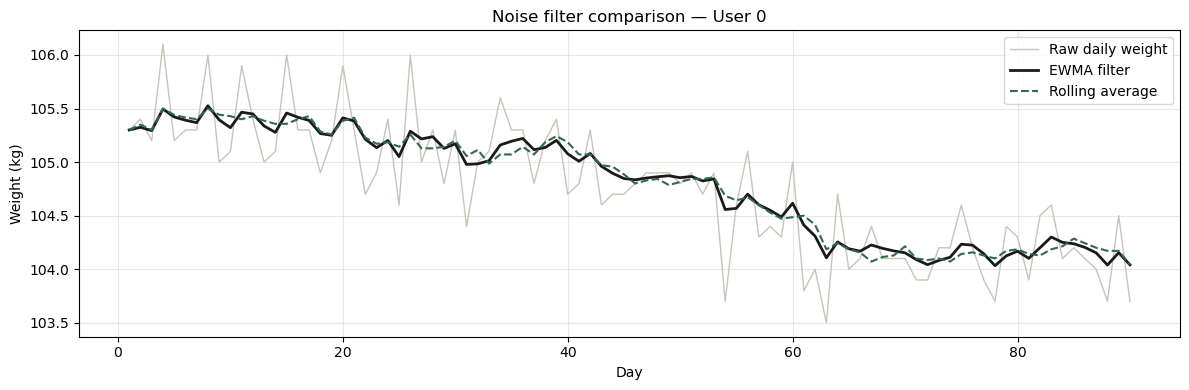

Noise filter working correctly


In [5]:
# Noise filter using Exponential Weighted Moving Average
def ewma_filter(weight_log, span=7):
    series = pd.Series(weight_log)
    smoothed = series.ewm(span=span, adjust=False).mean()
    return smoothed.values

# Rolling average filter for comparison
def rolling_filter(weight_log, window=7):
    series = pd.Series(weight_log)
    smoothed = series.rolling(window=window, min_periods=1).mean()
    return smoothed.values

# Test on one user
user_0 = df[df["user_id"] == 0]["weight"].values
days   = np.arange(1, len(user_0) + 1)

smoothed_ewma    = ewma_filter(user_0)
smoothed_rolling = rolling_filter(user_0)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(days, user_0, color="#C8C3BB", linewidth=1.0, label="Raw daily weight")
ax.plot(days, smoothed_ewma, color="#1A1A1A", linewidth=2.0, label="EWMA filter")
ax.plot(days, smoothed_rolling, color="#2D6A4F", linewidth=1.5, 
        linestyle="--", label="Rolling average")
ax.set_xlabel("Day")
ax.set_ylabel("Weight (kg)")
ax.set_title("Noise filter comparison — User 0")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Noise filter working correctly")


In [6]:
# Personal calorie estimator
# Fits a linear regression on smoothed weight trend
# and back-calculates the user's personal calorie balance

def estimate_calorie_balance(weight_log, kcal_per_kg=7700):
    smoothed = ewma_filter(weight_log)
    days     = np.arange(len(smoothed)).reshape(-1, 1)
    
    # Fit linear regression on smoothed trend
    model  = LinearRegression()
    model.fit(days, smoothed)
    
    # Slope = kg per day change
    kg_per_day = model.coef_[0]
    
    # Convert to calorie balance per day
    kcal_per_day = kg_per_day * kcal_per_kg
    
    return {
        "kg_per_day":        round(kg_per_day, 4),
        "kcal_per_day":      round(kcal_per_day, 1),
        "weekly_kg_change":  round(kg_per_day * 7, 3),
        "r_squared":         round(model.score(days, smoothed), 3)
    }

# Test on several users and compare inferred vs actual
print(f"{'User':<6} {'Goal':<10} {'Actual delta':>14} {'Inferred kcal/day':>18} {'Weekly change':>14}")
print("-" * 65)

for uid in range(10):
    user_data   = df[df["user_id"] == uid]
    weight_log  = user_data["weight"].values
    actual_delta = user_data["target_daily_delta"].iloc[0]
    
    result = estimate_calorie_balance(weight_log)
    
    print(f"{uid:<6} "
          f"{user_data['goal'].iloc[0]:<10} "
          f"{actual_delta:>14.1f} "
          f"{result['kcal_per_day']:>18.1f} "
          f"{result['weekly_kg_change']:>14.3f} kg")

User   Goal         Actual delta  Inferred kcal/day  Weekly change
-----------------------------------------------------------------
0      lose               -359.6             -140.5         -0.128 kg
1      gain                424.9              407.1          0.370 kg
2      lose               -425.1             -172.7         -0.157 kg
3      maintain              0.0                1.0          0.001 kg
4      lose               -249.3             -110.0         -0.100 kg
5      lose               -341.7             -198.5         -0.180 kg
6      lose               -242.4              -94.5         -0.086 kg
7      lose               -364.6             -294.1         -0.267 kg
8      lose               -481.5             -211.6         -0.192 kg
9      maintain              0.0               21.5          0.020 kg


Total readings:    90
Anomalies flagged: 9
Anomaly rate:      10.0%


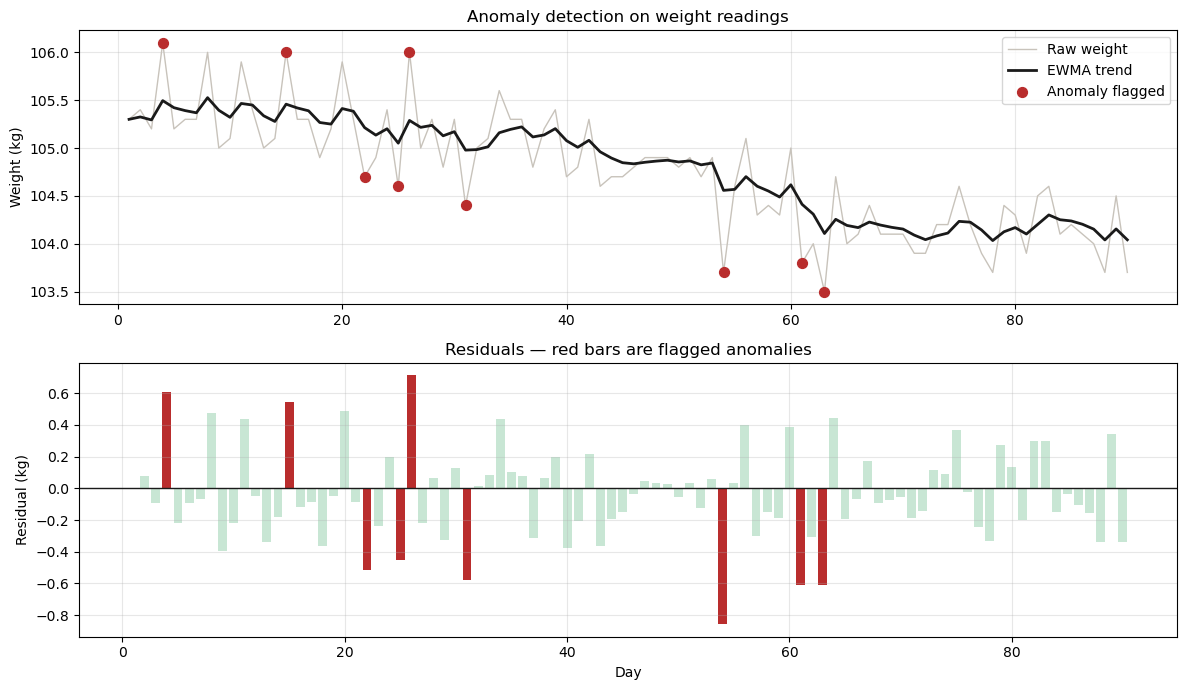

In [7]:
# Anomaly detector using Isolation Forest
def detect_anomalies(weight_log, contamination=0.1):
    smoothed  = ewma_filter(weight_log)
    residuals = np.array(weight_log) - smoothed
    
    # Fit Isolation Forest on residuals
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42
    )
    residuals_2d = residuals.reshape(-1, 1)
    predictions  = iso_forest.fit_predict(residuals_2d)
    
    # -1 means anomaly, 1 means normal
    anomaly_flags = predictions == -1
    
    return anomaly_flags, residuals

# Test on user 0
weight_log    = df[df["user_id"] == 0]["weight"].values
anomaly_flags, residuals = detect_anomalies(weight_log)
days          = np.arange(1, len(weight_log) + 1)
smoothed      = ewma_filter(weight_log)

print(f"Total readings:    {len(weight_log)}")
print(f"Anomalies flagged: {anomaly_flags.sum()}")
print(f"Anomaly rate:      {anomaly_flags.mean():.1%}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Top — weight with anomalies highlighted
axes[0].plot(days, weight_log, color="#C8C3BB", 
             linewidth=1.0, label="Raw weight")
axes[0].plot(days, smoothed, color="#1A1A1A", 
             linewidth=2.0, label="EWMA trend")
axes[0].scatter(days[anomaly_flags], weight_log[anomaly_flags],
                color="#B92D2D", s=50, zorder=5, label="Anomaly flagged")
axes[0].set_ylabel("Weight (kg)")
axes[0].set_title("Anomaly detection on weight readings")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom — residuals
axes[1].bar(days, residuals, color=[
    "#B92D2D" if f else "#C8E6D4" for f in anomaly_flags
], width=0.8)
axes[1].axhline(0, color="#1A1A1A", linewidth=1.0)
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Residual (kg)")
axes[1].set_title("Residuals — red bars are flagged anomalies")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Complete ML pipeline — combines all three modules
def run_ml_pipeline(weight_log, target_weekly_change=None, kcal_per_kg=7700):
    
    # Step 1 — filter noise
    smoothed      = ewma_filter(weight_log)
    
    # Step 2 — detect anomalies
    anomaly_flags, residuals = detect_anomalies(weight_log)
    
    # Step 3 — estimate calorie balance using clean readings only
    clean_weights = np.where(anomaly_flags, smoothed, weight_log)
    result        = estimate_calorie_balance(clean_weights)
    
    # Step 4 — calculate recommendation
    actual_kcal_per_day = result["kcal_per_day"]
    
    if target_weekly_change is not None:
        target_kcal_per_day = (target_weekly_change * kcal_per_kg) / 7
        gap                 = target_kcal_per_day - actual_kcal_per_day
        
        # Cap adjustment at 300 kcal to avoid extreme recommendations
        adjustment       = max(min(gap, 300), -300)
        food_adjustment  = round(adjustment * 0.6, 1)
        activity_adjustment = round(adjustment * 0.4, 1)
    else:
        target_kcal_per_day    = None
        gap                    = None
        food_adjustment        = None
        activity_adjustment    = None

    return {
        "smoothed_trend":       smoothed,
        "anomalies_detected":   int(anomaly_flags.sum()),
        "clean_readings":       int((~anomaly_flags).sum()),
        "inferred_kcal_per_day": actual_kcal_per_day,
        "weekly_kg_change":     result["weekly_kg_change"],
        "target_kcal_per_day":  target_kcal_per_day,
        "gap_kcal":             round(gap, 1) if gap else None,
        "food_adjustment":      food_adjustment,
        "activity_adjustment":  activity_adjustment,
        "r_squared":            result["r_squared"]
    }

# Test the full pipeline on user 0
weight_log = df[df["user_id"] == 0]["weight"].values
output     = run_ml_pipeline(weight_log, target_weekly_change=-0.5)

print("ML Pipeline Output — User 0")
print("=" * 40)
for key, value in output.items():
    if key != "smoothed_trend":
        print(f"  {key:<25}: {value}")

ML Pipeline Output — User 0
  anomalies_detected       : 9
  clean_readings           : 81
  inferred_kcal_per_day    : -133.1
  weekly_kg_change         : -0.121
  target_kcal_per_day      : -550.0
  gap_kcal                 : -416.9
  food_adjustment          : -180.0
  activity_adjustment      : -120.0
  r_squared                : 0.914
